# DOOM Agent Curriculum Learning

Progressive training through increasingly complex scenarios:
1. **Basic** - Simple aiming & shooting
2. **DefendCenter** - 360° turning (enemies from all sides)
3. **DefendLine** - Shooting + strafing under pressure
4. **HealthGathering** - Navigation & survival
5. **Corridor** - Full combat: navigation + shooting + turning

In [1]:
from datetime import datetime
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import vizdoom as vzd
import vizdoom.gymnasium_wrapper
from tqdm import tqdm

from mamba_model import SSDMamba2Combatant

# For inline plots in Jupyter
%matplotlib inline
plt.style.use("seaborn-v0_8-darkgrid")


def get_timestamp():
    """Get current timestamp for file naming."""
    return datetime.now().strftime("%Y%m%d_%H%M%S")

In [2]:
def plot_training_results(reward_history: list, stage_name: str, window: int = 100):
    """Plot learning curve and reward histogram for a training stage."""
    if not reward_history:
        print("No rewards to plot.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Learning Curve (smoothed)
    ax1 = axes[0]
    episodes = np.arange(len(reward_history))
    ax1.plot(episodes, reward_history, alpha=0.3, color="blue", label="Raw")

    # Moving average
    if len(reward_history) >= window:
        smoothed = np.convolve(reward_history, np.ones(window) / window, mode="valid")
        ax1.plot(
            np.arange(window - 1, len(reward_history)),
            smoothed,
            color="red",
            linewidth=2,
            label=f"{window}-episode MA",
        )

    ax1.set_xlabel("Episode")
    ax1.set_ylabel("Reward")
    ax1.set_title(f"{stage_name} - Learning Curve")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Reward Histogram
    ax2 = axes[1]
    ax2.hist(reward_history, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
    ax2.axvline(
        np.mean(reward_history),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {np.mean(reward_history):.1f}",
    )
    ax2.axvline(
        np.median(reward_history),
        color="orange",
        linestyle="--",
        linewidth=2,
        label=f"Median: {np.median(reward_history):.1f}",
    )
    ax2.set_xlabel("Reward")
    ax2.set_ylabel("Frequency")
    ax2.set_title(f"{stage_name} - Reward Distribution")
    ax2.legend()

    plt.tight_layout()
    plt.savefig(
        f"checkpoints/{stage_name.lower().replace(' ', '_')}_results.png", dpi=150
    )
    plt.show()

    # Print statistics
    print(f"\\n{stage_name} Statistics:")
    print(f"  Episodes: {len(reward_history)}")
    print(f"  Mean: {np.mean(reward_history):.2f}")
    print(f"  Std: {np.std(reward_history):.2f}")
    print(f"  Min: {np.min(reward_history):.2f}")
    print(f"  Max: {np.max(reward_history):.2f}")
    print(f"  Last 100 avg: {np.mean(reward_history[-100:]):.2f}")

In [3]:
import vizdoom.gymnasium_wrapper  # register Vizdoom envs

# Use -MultiBinary-v1 envs (max_buttons_pressed=0). Map curriculum id -> gym id.
GYM_ENV_IDS = {
    "VizdoomBasic-v1": "VizdoomBasic-MultiBinary-v1",
    "VizdoomCorridor-v1": "VizdoomCorridor-MultiBinary-v1",
    "VizdoomDefendCenter-v1": "VizdoomDefendCenter-MultiBinary-v1",
    "VizdoomDefendLine-v1": "VizdoomDefendLine-MultiBinary-v1",
    "VizdoomHealthGathering-v1": "VizdoomHealthGathering-MultiBinary-v1",
}

# Our 7 buttons: [Fwd, Back, Left, Right, TurnL, TurnR, Shoot] = indices 0..6
# Each scenario uses a subset. This table: env_id -> indices into our 7-dim to send.
# (Scenario default buttons are fixed by its cfg; we map our 7-dim to that subset.)
SCENARIO_BUTTON_INDICES = {
    "VizdoomBasic-v1": [2, 3, 6],           # Left, Right, Attack
    "VizdoomCorridor-v1": list(range(7)),   # all 7
    "VizdoomDefendCenter-v1": [4, 5, 6],    # TurnL, TurnR, Attack
    "VizdoomDefendLine-v1": [4, 5, 6],      # TurnL, TurnR, Attack
    "VizdoomHealthGathering-v1": [0, 4, 5], # Fwd, TurnL, TurnR
}


class ExtractScreenWrapper(gym.ObservationWrapper):
    """Extract only the screen image buffer from ViZDoom's Dict."""

    def __init__(self, env):
        super().__init__(env)
        self.observation_space = env.observation_space.spaces["screen"]

    def observation(self, obs):
        return obs["screen"]


class CombatActionWrapper(gym.ActionWrapper):
    """Maps multi-discrete [3,3,3,2] to 7-button binary, then selects subset for this scenario."""

    def __init__(self, env, button_indices=None):
        super().__init__(env)
        self.button_indices = button_indices if button_indices is not None else list(range(7))

    def action(self, action):
        new_action = np.zeros(7, dtype=np.int32)
        if action[0] == 1:
            new_action[0] = 1
        elif action[0] == 2:
            new_action[1] = 1
        if action[1] == 1:
            new_action[2] = 1
        elif action[1] == 2:
            new_action[3] = 1
        if action[2] == 1:
            new_action[4] = 1
        elif action[2] == 2:
            new_action[5] = 1
        if action[3] == 1:
            new_action[6] = 1
        return new_action[self.button_indices].copy()


def make_env(env_id: str, seed: int):
    """Create a ViZDoom environment. Uses -MultiBinary-v1 and scenario button subset."""
    gym_id = GYM_ENV_IDS.get(env_id, "VizdoomCorridor-MultiBinary-v1")
    indices = SCENARIO_BUTTON_INDICES.get(env_id, list(range(7)))

    def thunk():
        env = gym.make(gym_id, render_mode="rgb_array")
        env = ExtractScreenWrapper(env)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        env = gym.wrappers.GrayscaleObservation(env, keep_dim=True)
        env = gym.wrappers.FrameStackObservation(env, 4)
        env = CombatActionWrapper(env, button_indices=indices)
        return env

    return thunk

In [4]:
def train_stage(
    env_id: str,
    agent,
    total_timesteps: int,
    checkpoint_path: str,
    num_envs: int = 56,
    num_steps: int = 128,
    lr: float = 2.5e-4,
    entropy_coef: float = 0.05,
    ppo_epochs: int = 8,
    batch_size: int = 512,
    gamma: float = 0.99,
    gae_lambda: float = 0.95,
    clip_coef: float = 0.2,
):
    """Train agent on a specific environment stage."""
    device = next(agent.parameters()).device

    # Create environments
    envs = gym.vector.AsyncVectorEnv([make_env(env_id, i) for i in range(num_envs)])

    # Optimizer (fresh for each stage to reset momentum)
    optimizer = optim.Adam(agent.parameters(), lr=lr, eps=1e-5)

    # Buffers
    rollout_size = num_envs * num_steps
    num_heads = len(agent.action_dims)

    obs_buf = torch.zeros(
        (num_steps, num_envs) + envs.single_observation_space.shape, device=device
    )
    actions_buf = torch.zeros((num_steps, num_envs, num_heads), device=device)
    logprobs_buf = torch.zeros((num_steps, num_envs), device=device)
    rewards_buf = torch.zeros((num_steps, num_envs), device=device)
    dones_buf = torch.zeros((num_steps, num_envs), device=device)
    values_buf = torch.zeros((num_steps, num_envs), device=device)

    # Pinned memory for fast transfers
    next_obs_cpu = torch.zeros(
        (num_envs,) + envs.single_observation_space.shape, pin_memory=True
    )
    next_done_cpu = torch.zeros(num_envs, pin_memory=True)
    reward_cpu = torch.zeros(num_envs, pin_memory=True)

    # Initialize
    obs_np, _ = envs.reset()
    next_obs_cpu.copy_(torch.from_numpy(obs_np))
    next_obs = next_obs_cpu.to(device, non_blocking=True)
    next_done = torch.zeros(num_envs, device=device)

    global_step = 0
    episodic_rewards = np.zeros(num_envs)
    reward_history = []

    num_updates = total_timesteps // rollout_size
    progress_bar = tqdm(range(num_updates), desc=f"Training {env_id}")

    for _ in progress_bar:
        # --- ROLLOUT ---
        for step in range(num_steps):
            global_step += num_envs
            obs_buf[step] = next_obs
            dones_buf[step] = next_done

            with torch.inference_mode():
                action, logprob, _, value = agent.get_action_and_value(next_obs)
                values_buf[step] = value.flatten()

            actions_buf[step] = action
            logprobs_buf[step] = logprob

            action_np = action.cpu().numpy()
            obs_np, reward_np, term, trunc, info = envs.step(action_np)

            reward_cpu.copy_(torch.from_numpy(reward_np))
            rewards_buf[step] = reward_cpu.to(device, non_blocking=True)

            episodic_rewards += reward_np
            done_mask = np.logical_or(term, trunc)
            for i in np.where(done_mask)[0]:
                reward_history.append(episodic_rewards[i])
                episodic_rewards[i] = 0

            next_done_cpu.copy_(torch.from_numpy(done_mask.astype(np.float32)))
            next_done = next_done_cpu.to(device, non_blocking=True)
            next_obs_cpu.copy_(torch.from_numpy(obs_np))
            next_obs = next_obs_cpu.to(device, non_blocking=True)

        # --- GAE ---
        if device.type == "cuda":
            torch.cuda.synchronize()

        with torch.inference_mode():
            _, _, _, next_value = agent.get_action_and_value(next_obs)
            next_value = next_value.reshape(1, -1)
            advantages = torch.zeros_like(rewards_buf)
            lastgaelam = 0
            for t in reversed(range(num_steps)):
                if t == num_steps - 1:
                    nextnonterminal = 1.0 - next_done
                    next_v = next_value
                else:
                    nextnonterminal = 1.0 - dones_buf[t + 1]
                    next_v = values_buf[t + 1]
                delta = (
                    rewards_buf[t] + gamma * next_v * nextnonterminal - values_buf[t]
                )
                advantages[t] = lastgaelam = (
                    delta + gamma * gae_lambda * nextnonterminal * lastgaelam
                )
            returns = advantages + values_buf

        # --- PPO UPDATE ---
        b_obs = obs_buf.reshape((-1,) + envs.single_observation_space.shape)
        b_logprobs = logprobs_buf.reshape(-1)
        b_actions = actions_buf.reshape((-1, num_heads))
        b_advantages = advantages.reshape(-1)
        b_returns = returns.reshape(-1)

        for epoch in range(ppo_epochs):
            inds = np.arange(rollout_size)
            np.random.shuffle(inds)
            for start in range(0, rollout_size, batch_size):
                mb_inds = inds[start : start + batch_size]

                _, newlogprob, entropy, newvalue = agent.get_action_and_value(
                    b_obs[mb_inds], b_actions[mb_inds]
                )

                logratio = newlogprob - b_logprobs[mb_inds]
                ratio = logratio.exp()

                mb_adv = b_advantages[mb_inds]
                mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)

                pg_loss1 = -mb_adv * ratio
                pg_loss2 = -mb_adv * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
                pg_loss = torch.max(pg_loss1, pg_loss2).mean()

                v_loss = 0.5 * ((newvalue.flatten() - b_returns[mb_inds]) ** 2).mean()
                entropy_loss = entropy.mean()

                loss = pg_loss - entropy_coef * entropy_loss + v_loss

                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(agent.parameters(), 0.5)
                optimizer.step()

        avg_reward = np.mean(reward_history[-100:]) if reward_history else 0
        progress_bar.set_postfix(
            {"Score": f"{avg_reward:.1f}", "Loss": f"{loss.item():.1f}"}
        )

    # Cleanup
    envs.close()

    # Save checkpoint with timestamp
    timestamp = get_timestamp()
    base_path = Path(checkpoint_path)
    timestamped_path = (
        base_path.parent / f"{base_path.stem}_{timestamp}{base_path.suffix}"
    )

    torch.save(agent.state_dict(), timestamped_path)
    print(f"Saved checkpoint to {timestamped_path}")

    # Also save as "latest" for easy access
    torch.save(agent.state_dict(), checkpoint_path)
    print(f"Saved latest to {checkpoint_path}")

    return reward_history, str(timestamped_path)

In [5]:
# Initialize device and agent
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

agent = SSDMamba2Combatant().to(device)
agent = torch.compile(agent, mode="reduce-overhead")

# Create checkpoints directory
Path("checkpoints").mkdir(exist_ok=True)

Using device: cuda


## Stage 1: Basic Shooting
Learn to aim and shoot at a stationary target. Simple reward structure.

In [6]:
# Stage 1: Basic - Learn shooting fundamentals
history_basic, ckpt_basic = train_stage(
    env_id="VizdoomBasic-v1",
    agent=agent,
    total_timesteps=500_000,  # Short stage, simple task
    checkpoint_path="checkpoints/stage1_basic.pth",
    entropy_coef=0.1,  # High exploration for initial learning
)
print(f"Checkpoint: {ckpt_basic}")

/home/kir/Code/DOOM/.venv/lib/python3.13/site-packages/vizdoom/gymnasium_wrapper/base_gymnasium_env.py:109: UserWarning: Detected screen format CRCGCB. Only RGB24 and GRAY8 are supported in the Gymnasium wrapper. Forcing RGB24.
  warnings.warn(
Training VizdoomBasic-v1: 100%|██████████| 69/69 [07:17<00:00,  6.34s/it, Score=61.9, Loss=1.5]  

Saved checkpoint to checkpoints/stage1_basic_20260125_200107.pth
Saved latest to checkpoints/stage1_basic.pth
Checkpoint: checkpoints/stage1_basic_20260125_200107.pth


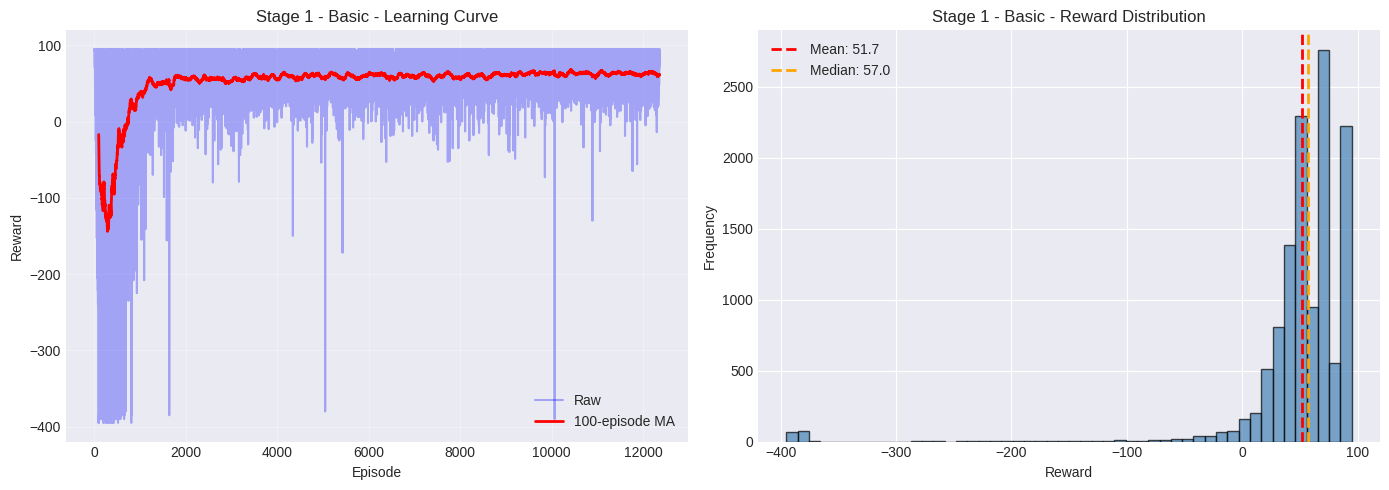

\nStage 1 - Basic Statistics:
  Episodes: 12357
  Mean: 51.66
  Std: 57.76
  Min: -395.00
  Max: 95.00
  Last 100 avg: 61.94


In [7]:
plot_training_results(history_basic, "Stage 1 - Basic")

## Stage 2: DefendCenter (CRITICAL)
Enemies spawn from ALL directions (360°). Forces learning to turn BOTH left AND right.
This is the key stage to fix the "only shoots left" problem.

In [ ]:
# Stage 2: DefendCenter - Learn 360° awareness and turning
history_defend_center, ckpt_defend_center = train_stage(
    env_id="VizdoomDefendCenter-v1",
    agent=agent,
    total_timesteps=2_000_000,  # Longer - this is critical skill
    checkpoint_path="checkpoints/stage2_defend_center.pth",
    entropy_coef=0.05,  # Moderate exploration
)
print(f"Checkpoint: {ckpt_defend_center}")

/home/kir/Code/DOOM/.venv/lib/python3.13/site-packages/vizdoom/gymnasium_wrapper/base_gymnasium_env.py:109: UserWarning: Detected screen format CRCGCB. Only RGB24 and GRAY8 are supported in the Gymnasium wrapper. Forcing RGB24.
  warnings.warn(
Training VizdoomDefendCenter-v1:   1%|▏         | 4/279 [00:24<28:21,  6.19s/it, Score=-0.1, Loss=1.0]

In [ ]:
plot_training_results(history_defend_center, "Stage 2 - DefendCenter")

## Stage 3: DefendLine
Enemies approach in waves. Learn to shoot accurately while under time pressure.

In [ ]:
# Stage 3: DefendLine - Shooting under pressure + strafing
history_defend_line, ckpt_defend_line = train_stage(
    env_id="VizdoomDefendLine-v1",
    agent=agent,
    total_timesteps=1_500_000,
    checkpoint_path="checkpoints/stage3_defend_line.pth",
    entropy_coef=0.03,  # Lower - refining existing skills
)
print(f"Checkpoint: {ckpt_defend_line}")

In [ ]:
plot_training_results(history_defend_line, "Stage 3 - DefendLine")

## Stage 4: HealthGathering
Navigate environment to collect health packs. Learn spatial awareness and movement.

In [ ]:
# Stage 4: HealthGathering - Navigation skills
history_health, ckpt_health = train_stage(
    env_id="VizdoomHealthGathering-v1",
    agent=agent,
    total_timesteps=1_500_000,
    checkpoint_path="checkpoints/stage4_health.pth",
    entropy_coef=0.05,  # Need exploration for navigation
)
print(f"Checkpoint: {ckpt_health}")

In [ ]:
plot_training_results(history_health, "Stage 4 - HealthGathering")

## Stage 5: Corridor (Final)
Combine all skills: navigate corridor while killing enemies on both sides.

In [ ]:
# Stage 5: Corridor - Full combat scenario
history_corridor, ckpt_corridor = train_stage(
    env_id="VizdoomCorridor-v1",
    agent=agent,
    total_timesteps=3_000_000,  # Longest stage - combining all skills
    checkpoint_path="checkpoints/stage5_corridor.pth",
    entropy_coef=0.02,  # Low - fine-tuning
)
print(f"Checkpoint: {ckpt_corridor}")

In [ ]:
plot_training_results(history_corridor, "Stage 5 - Corridor")

In [ ]:
# Save final model with timestamp
final_timestamp = get_timestamp()
final_model_path = f"ssd_mamba2_vizdoom_ppo_{final_timestamp}.pth"
torch.save(agent.state_dict(), final_model_path)
print(f"Final model saved to: {final_model_path}")

# Also save as default name for easy eval.py usage
torch.save(agent.state_dict(), "ssd_mamba2_vizdoom_ppo.pth")
print("Also saved as: ssd_mamba2_vizdoom_ppo.pth (default)")

In [ ]:
# Compare all stages
fig, ax = plt.subplots(figsize=(12, 6))

all_histories = [
    ("Basic", history_basic),
    ("DefendCenter", history_defend_center),
    ("DefendLine", history_defend_line),
    ("HealthGathering", history_health),
    ("Corridor", history_corridor),
]

means = [np.mean(h) for _, h in all_histories]
stds = [np.std(h) for _, h in all_histories]
names = [n for n, _ in all_histories]

x = np.arange(len(names))
bars = ax.bar(x, means, yerr=stds, capsize=5, color="steelblue", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.set_ylabel("Mean Reward")
ax.set_title("Curriculum Learning - Performance Across Stages")
ax.grid(True, alpha=0.3, axis="y")

# Add value labels on bars
for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{mean:.0f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("checkpoints/curriculum_summary.png", dpi=150)
plt.show()

## Utility: Load from checkpoint
Use this to resume training from any stage.

In [ ]:
def load_checkpoint(agent, checkpoint_path: str):
    """Load a checkpoint, handling torch.compile prefix."""
    state_dict = torch.load(checkpoint_path, weights_only=True)
    # Handle torch.compile() prefix
    state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}

    # Get underlying model if compiled
    if hasattr(agent, "_orig_mod"):
        agent._orig_mod.load_state_dict(state_dict)
    else:
        agent.load_state_dict(state_dict)
    print(f"Loaded checkpoint from {checkpoint_path}")


# Example: load from stage 2
# load_checkpoint(agent, "checkpoints/stage2_defend_center.pth")